In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk

ECG length: 50000
First few samples:


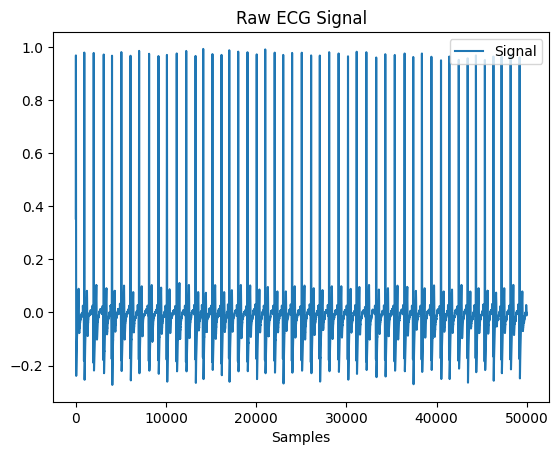

In [3]:
# Download ECG Dataset

# Load built-in NeuroKit ECG dataset sampled at 1000 Hz
ecg = nk.data("ecg_1000hz.csv")

print("ECG length:", len(ecg))
print("First few samples:")

# Visualize ECG signal
nk.signal_plot(ecg)
plt.title("Raw ECG Signal")
plt.show()

Detected R-peaks: 50


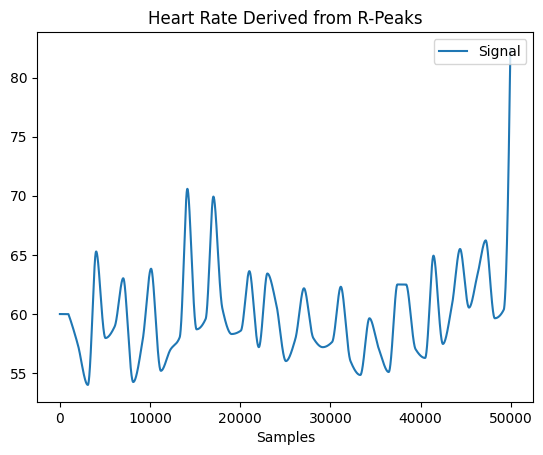

In [4]:
# Extract ECG Features

# Detect R-peaks
rpeaks, info = nk.ecg_peaks(ecg, sampling_rate=1000)

print("Detected R-peaks:", len(info["ECG_R_Peaks"]))

# Compute instantaneous heart rate
ecg_rate = nk.ecg_rate(
    rpeaks,
    sampling_rate=1000,
    desired_length=len(ecg)
)

# Plot heart rate signal
nk.signal_plot(ecg_rate)
plt.title("Heart Rate Derived from R-Peaks")
plt.show()


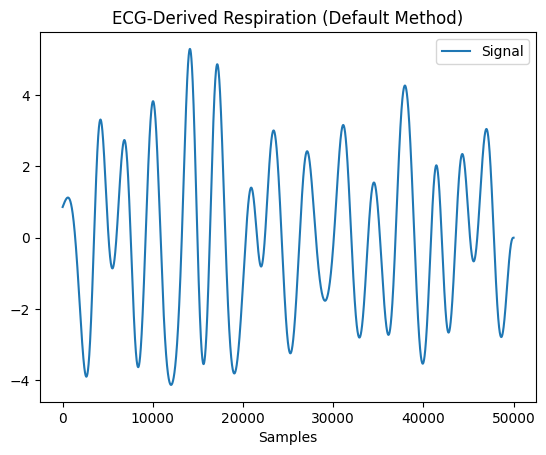

In [5]:
# Analyze ECG-Derived Respiration (EDR)

# Default method = Van Gent et al.
edr = nk.ecg_rsp(ecg_rate, sampling_rate=1000)

# Plot EDR signal
nk.signal_plot(edr)
plt.title("ECG-Derived Respiration (Default Method)")
plt.show()

   Van Gent et al.  Charlton et al.  Soni et al.  Sarkar et al.
0         0.861960         0.442188    59.984601       0.765160
1         0.862630         0.442312    59.984378       0.765496
2         0.863299         0.442437    59.984155       0.765834
3         0.863968         0.442562    59.983932       0.766173
4         0.864638         0.442688    59.983708       0.766514


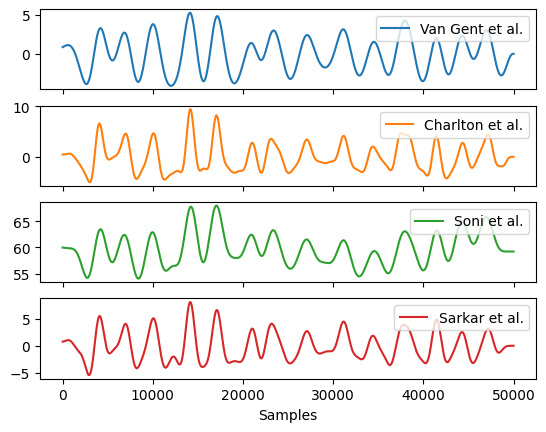

In [6]:
# Compare Different EDR Methods

edr_df = pd.DataFrame({
    "Van Gent et al.": nk.ecg_rsp(
        ecg_rate,
        sampling_rate=1000
    ),
    
    "Charlton et al.": nk.ecg_rsp(
        ecg_rate,
        sampling_rate=1000,
        method="charlton2016"
    ),
    
    "Soni et al.": nk.ecg_rsp(
        ecg_rate,
        sampling_rate=1000,
        method="soni2019"
    ),
    
    "Sarkar et al.": nk.ecg_rsp(
        ecg_rate,
        sampling_rate=1000,
        method="sarkar2015"
    )
})

# Display first rows
print(edr_df.head())

# Plot all methods separately
nk.signal_plot(edr_df, subplots=True)
plt.show()


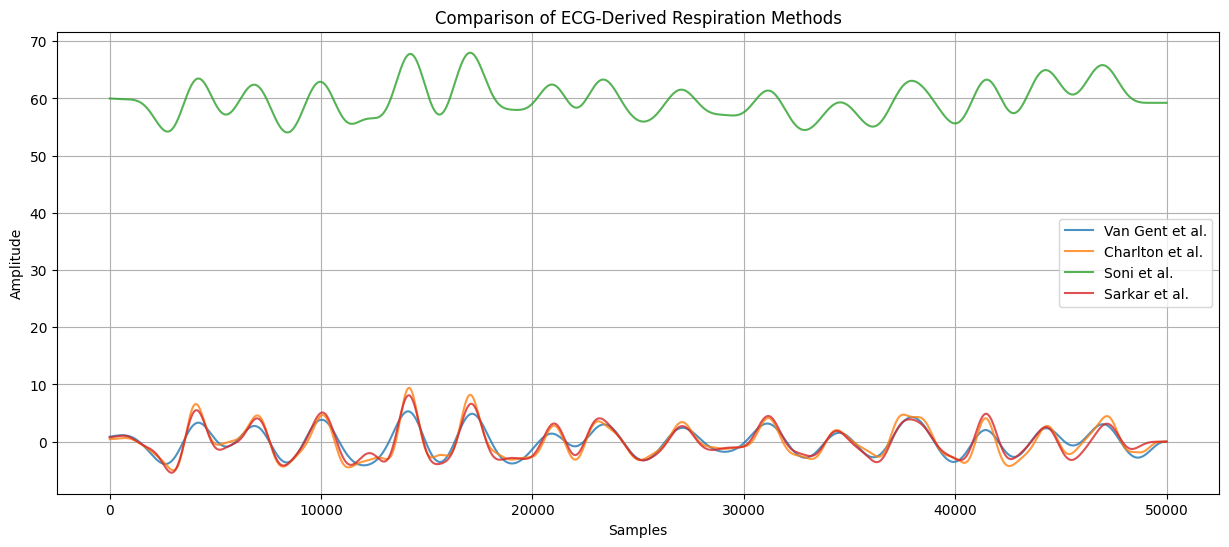

In [7]:
# Overlay all methods in one plot

plt.figure(figsize=(15,6))
for col in edr_df.columns:
    plt.plot(edr_df[col], label=col, alpha=0.8)

plt.title("Comparison of ECG-Derived Respiration Methods")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Summary Statistics

print("\nSummary Statistics:")
print(edr_df.describe())


Summary Statistics:
       Van Gent et al.  Charlton et al.   Soni et al.  Sarkar et al.
count     50000.000000     50000.000000  50000.000000   50000.000000
mean         -0.012711        -0.010425     59.702678      -0.017907
std           2.259631         2.823059      3.013297       2.669214
min          -4.135471        -5.010305     54.050597      -5.427810
25%          -1.895594        -2.337066     57.416508      -2.222482
50%          -0.039375        -0.494352     59.349243      -0.439531
75%           1.730385         1.968531     61.734234       1.929165
max           5.301806         9.402786     67.985215       8.105689
